In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv('economic_index.csv')

In [122]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [123]:
df.tail()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
19,19,2016,5,1.75,6.1,866
20,20,2016,4,1.75,5.9,876
21,21,2016,3,1.75,6.2,822
22,22,2016,2,1.75,6.2,704
23,23,2016,1,1.75,6.1,719


In [124]:
df.isna().sum()

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [125]:
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [126]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


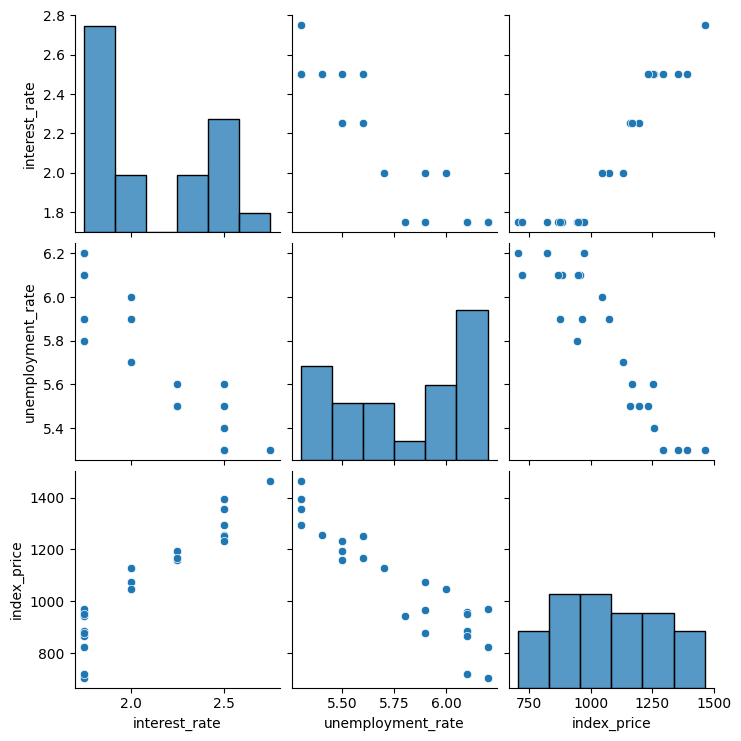

In [127]:
sns.pairplot(df)

In [128]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

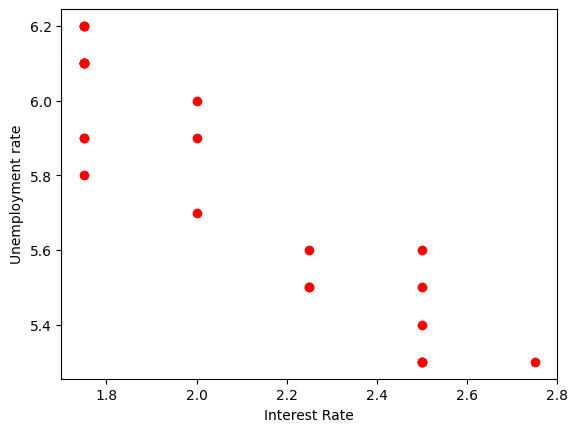

In [129]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel("Interest Rate")
plt.ylabel('Unemployment rate')

In [130]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [131]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [132]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [133]:
from sklearn.model_selection import train_test_split

In [134]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

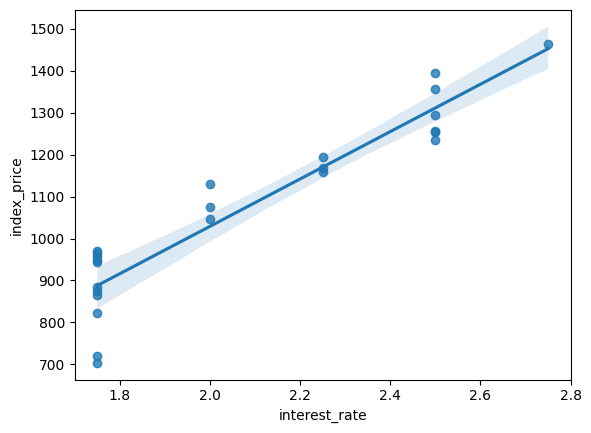

In [135]:
sns.regplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

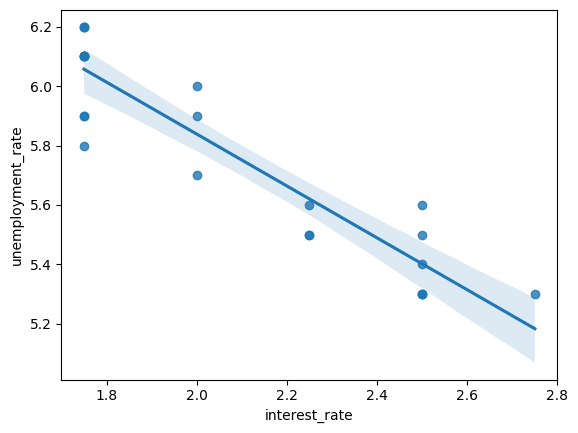

In [136]:
sns.regplot(x='interest_rate',y='unemployment_rate',data=df)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

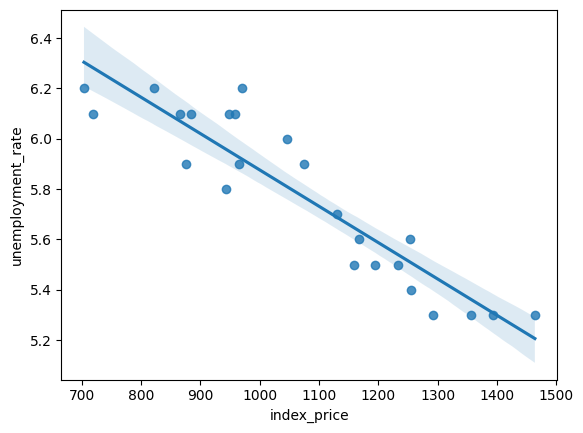

In [137]:
sns.regplot(x='index_price',y='unemployment_rate',data=df)

In [138]:
from sklearn.preprocessing import StandardScaler

In [139]:
scalar=StandardScaler()

In [140]:
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [141]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [142]:
from sklearn.linear_model import LinearRegression

In [143]:
reg=LinearRegression()

In [144]:
reg.fit(X_train,y_train)

LinearRegression()

In [145]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(reg,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [146]:
validation_score=np.mean(validation_score)
print(validation_score)

-5914.828180162386


In [147]:
y_pred=reg.predict(X_test)

In [148]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [149]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [150]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)

0.8278978091457145


In [151]:
r2_adj=1 - ((1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print(r2_adj)

0.7131630152428576


### Assumptions


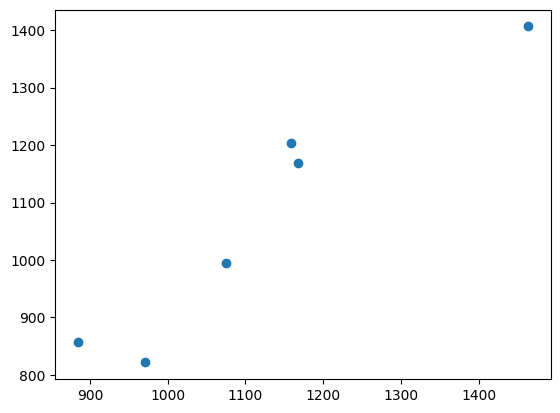

In [ ]:
plt.scatter(y_test,y_pred)

In [153]:
residuals=y_test-y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


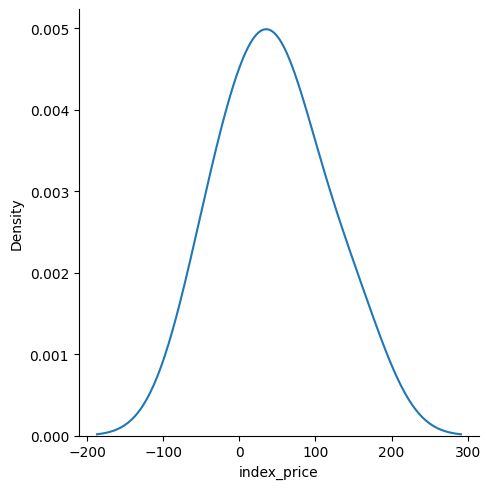

In [155]:
### plot residuals
sns.displot(residuals,kind='kde')

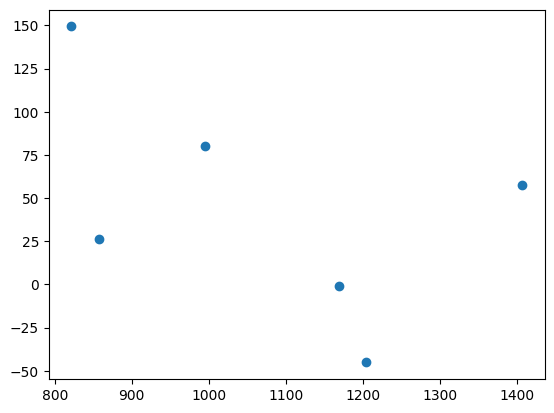

In [156]:
## create a scatter plot wrt to predictions and residuals

plt.scatter(y_pred,residuals)